In [ ]:
print("24BAD035-IBRAHIM")
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

24BAD035-IBRAHIM


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

histories = {}

In [ ]:
for name, optimizer in optimizers.items():

    print("\nTraining with", name)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    histories[name] = history

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"{name}")
    print("Test Loss :", round(loss, 4))
    print("Test Accuracy :", round(accuracy, 4))


Training with SGD
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8147 - loss: 0.6987 - val_accuracy: 0.9057 - val_loss: 0.3397
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9077 - loss: 0.3237 - val_accuracy: 0.9225 - val_loss: 0.2712
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9234 - loss: 0.2681 - val_accuracy: 0.9319 - val_loss: 0.2375
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9328 - loss: 0.2317 - val_accuracy: 0.9398 - val_loss: 0.2151
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9397 - loss: 0.2056 - val_accuracy: 0.9458 - val_loss: 0.1931
SGD
Test Loss : 0.1944
Test Accuracy : 0.9425

Training with Momentum
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9061 - loss: 0.3143 - val_accuracy: 0.9587 - val_loss: 0.1426
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9609 - loss: 0.1314 - val_accuracy: 0.9663 - val_loss: 0.1108
Epoch 3/

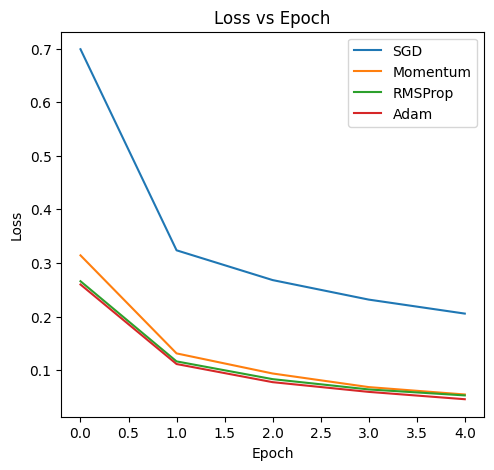

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

for name in histories:
    plt.plot(histories[name].history["loss"], label=name)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

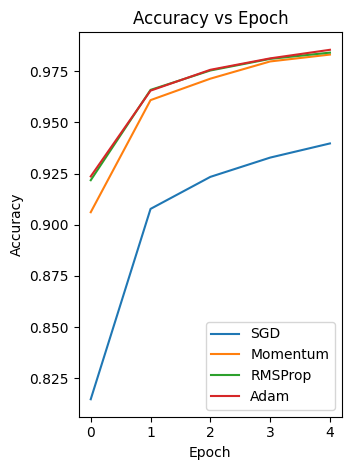

In [ ]:
plt.subplot(1,2,2)

for name in histories:
    plt.plot(histories[name].history["accuracy"], label=name)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()